In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data_files = {"unsw_nb15_1.csv",
              "unsw_nb15_2.csv",
              "unsw_nb15_3.csv",
              "unsw_nb15_4.csv"}             
features = pd.read_csv("unsw_nb15_features.csv", encoding='cp1252')
data = pd.concat([pd.read_csv(file, low_memory=False, header=None) for file in data_files], ignore_index=True) 
data.head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [2]:
column_names = features["Name"].to_list()
column_names = [name.lower() for name in column_names]
# try to make the column names more readable
def update_column_names(name: str) -> str:
    name = name.strip().lower()
    rename_map = {
        "dur": "duration",
        "proto": "protocol",
        "ltime": "last_time",
        "attack_cat": "attack_category",
    }
    if name in rename_map:
        return rename_map[name]
    s_whitelist = {"state", "service", "synack"}
    if name in s_whitelist:
        return name
    if name.startswith("src") and not name.startswith("src_"):
        return name.replace("src", "src_", 1)
    if name.startswith("dst") and not name.startswith("dst_"):
        return name.replace("dst", "dst_", 1)
    if name.startswith("ds"):
        return name.replace("ds", "dst_", 1)
    if name.startswith("s"):
        return name.replace("s", "src_", 1)
    if name.startswith("d"):
        return name.replace("d", "dst_", 1)
    if name.startswith("tcp") and not name.startswith("tcp_"):
        return name.replace("tcp", "tcp_", 1)
    return name
column_names = [update_column_names(name) for name in column_names]
data.columns = column_names

data["src_time"] = pd.to_datetime(data["src_time"], unit='s')
data["last_time"] = pd.to_datetime(data["last_time"], unit='s')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column            Dtype         
---  ------            -----         
 0   src_ip            object        
 1   src_port          object        
 2   dst_ip            object        
 3   dst_port          object        
 4   protocol          object        
 5   state             object        
 6   duration          float64       
 7   src_bytes         int64         
 8   dst_bytes         int64         
 9   src_ttl           int64         
 10  dst_ttl           int64         
 11  src_loss          int64         
 12  dst_loss          int64         
 13  service           object        
 14  src_load          float64       
 15  dst_load          float64       
 16  src_pkts          int64         
 17  dst_pkts          int64         
 18  src_win           int64         
 19  dst_win           int64         
 20  src_tcpb          int64         
 21  dst_tcpb

In [3]:
# check for nulls
null_data = data.copy().isnull().sum()
filtered_null_data = null_data.where(null_data > 0).dropna()
print(filtered_null_data)
print("\n")

# check if null attack_category means benign
null_attack_categories = data[data["attack_category"].isna()].value_counts(subset=["label"])
print(null_attack_categories)
print("\n")

# fill null attack categories with benign
data["attack_category"] = data["attack_category"].fillna("benign")
# null ftp_logins can be assumed to be not applicable to the row
data["is_ftp_login"] = data["is_ftp_login"].fillna(0)
# null ct_flw_http_mthd is non applicable so count can be 0
data["ct_flw_http_mthd"] = data["ct_flw_http_mthd"].fillna(0)

# check again
new_null_data = data.isnull().sum()
new_filtered_null_data = new_null_data.where(new_null_data > 0).dropna()
print(new_filtered_null_data)
print("\n")

# format attack category values
data["attack_category"] = data["attack_category"].str.strip()
data["attack_category"] = data["attack_category"].str.lower()
data["attack_category"] = data["attack_category"].replace("backdoor", "backdoors")
print(data["attack_category"].value_counts())
print("\n")

# relabel unknown services
data["service"] = data["service"].replace("-", "unknown")
print(data["service"].value_counts())

ct_flw_http_mthd    1348145.0
is_ftp_login        1429879.0
attack_category     2218764.0
dtype: float64


label
0        2218764
Name: count, dtype: int64


Series([], dtype: float64)


attack_category
benign            2218764
generic            215481
exploits            44525
fuzzers             24246
dos                 16353
reconnaissance      13987
analysis             2677
backdoors            2329
shellcode            1511
worms                 174
Name: count, dtype: int64


service
unknown     1246397
dns          781668
http         206273
ftp-data     125783
smtp          81645
ftp           49090
ssh           47160
pop3           1533
dhcp            172
ssl             142
snmp            113
radius           40
irc              31
Name: count, dtype: int64


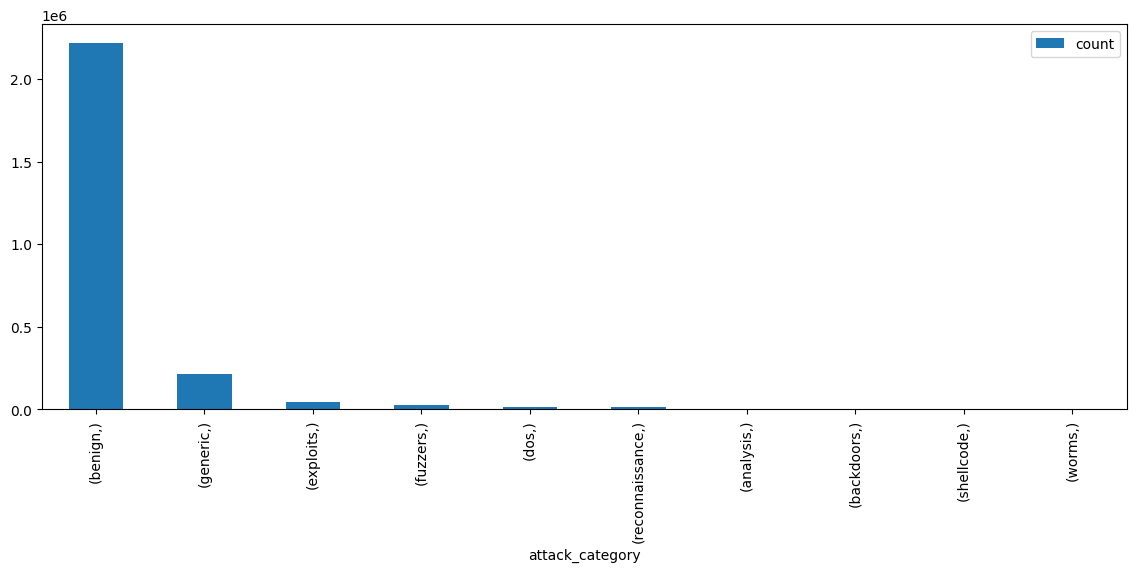

In [4]:
# category distribution
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
attack_category_distribution = data.value_counts(subset=["attack_category"]).to_frame()
attack_category_distribution.plot(kind='bar', ax=ax)
plt.show()

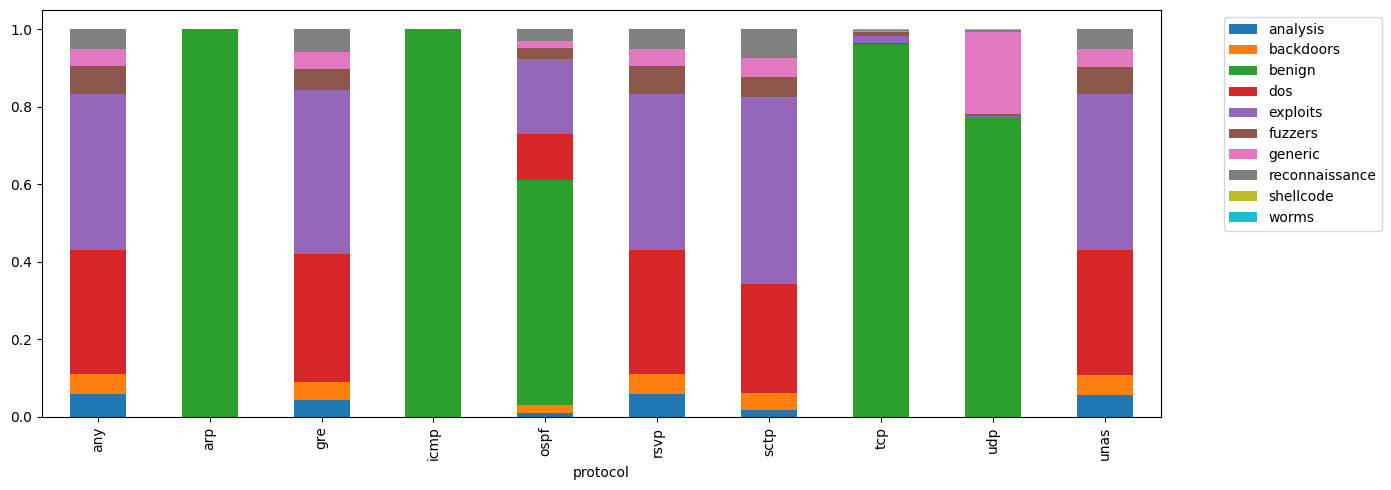

In [5]:
# top protocols
top_protocols = data["protocol"].value_counts().head(10).index

# frequency distribution of top protocol by attack category
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
is_top_protocol = data["protocol"].isin(top_protocols)
protocol_attack_category = pd.crosstab(data[is_top_protocol]["protocol"], data[is_top_protocol]["attack_category"], normalize='index')
protocol_attack_category.plot(kind='bar', stacked=True, ax=ax)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

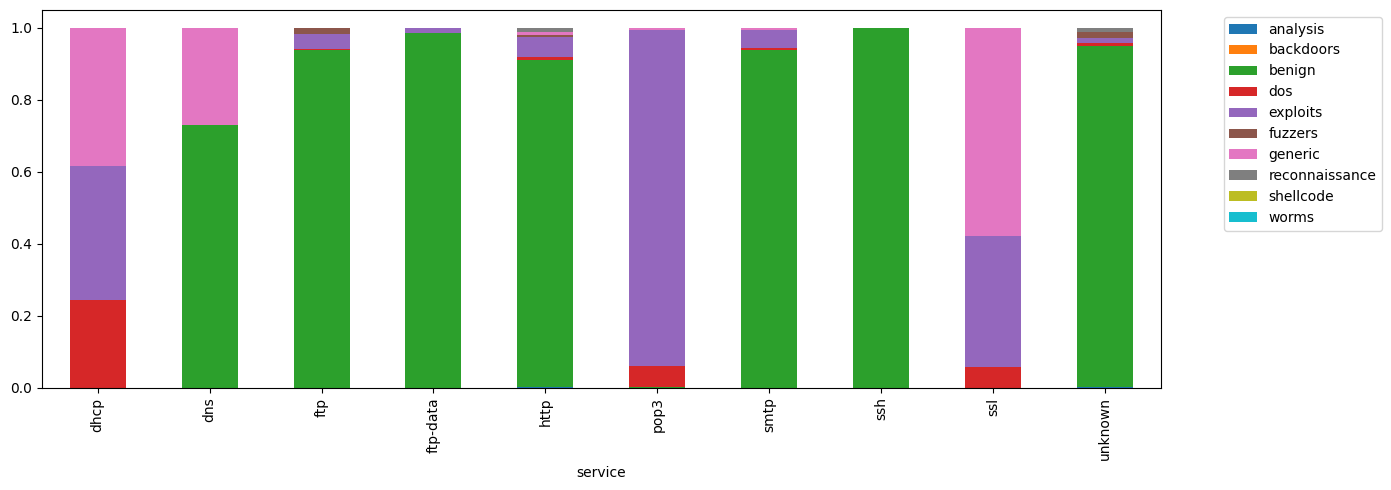

In [6]:
# top services
top_services = data["service"].value_counts().head(10).index

# frequency distribution of top services by attack category
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
is_top_service = data["service"].isin(top_services)
service_attack_category = pd.crosstab(data[is_top_protocol]["service"], data[is_top_service]["attack_category"], normalize='index')
service_attack_category.plot(kind='bar', stacked=True, ax=ax)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'log_duration'}, xlabel='attack_category'>

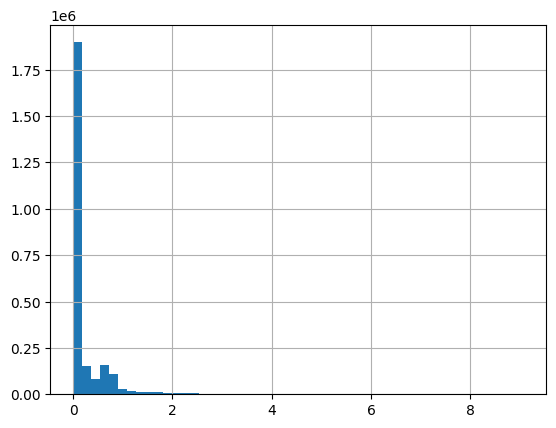

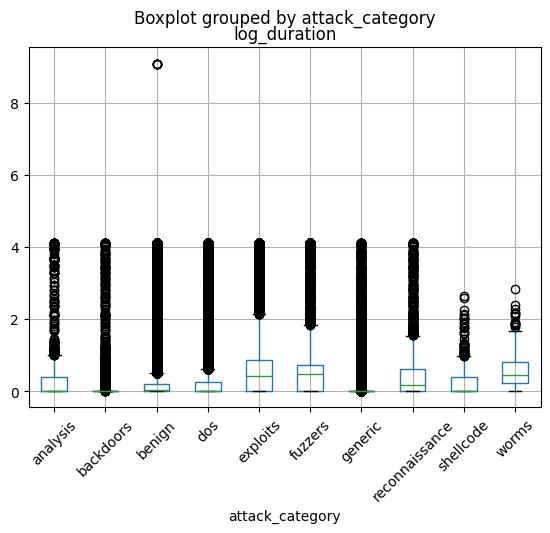

In [7]:
# taking a peek at durations
np.log1p(data["duration"]).hist(bins=50)

# top attacks
top_attacks = data['attack_category'].value_counts().head(10).index
subset = data[data['attack_category'].isin(top_attacks)]

# most durations are small but there appears to be a lot of outliers 
subset['log_duration'] = np.log1p(subset['duration'])
subset.boxplot(column='log_duration', by='attack_category', rot=45)